# Импорт библиотек

In [2]:
# Импорт библиотек
import pandas            as pd
import numpy             as np
from   scipy         import stats

import seaborn           as sns
import matplotlib.pyplot as plt

# Стили графиков

In [3]:
sns.set_theme()

# Импорт датафреймов

In [4]:
# Пути и имена к датафреймам
# *Все пути указаны относительно корневой папки исполняемого файла
df_path_original  = './CSV/Original' # Путь к исходним CSV файлам
df_path_modern    = './CSV/Modern'   # Путь к новым CSV файлом, созданых при помощи запросов в SQL

# Названия CSV файлов
df_original_names = {'events':   'events.csv',
                     'orders':   'orders.csv',
                     'products': 'products.csv',
                     'users':    'users.csv',
                     'actions':  'actions.csv'}

In [5]:
# Импорт базовых датафрейма
for name in df_original_names:
    globals()[name] = pd.read_csv(f'{df_path_original}/{df_original_names[name]}')

## Просмотр датафреймов

In [6]:
events.head(3)

,event_id,user_id,event_type,event_time,device
0,1,1,registration,2022-02-09 00:36:00,mobile
1,2,1,view_product,2022-02-09 00:51:00,mobile
2,3,1,add_to_cart,2022-02-09 00:58:00,mobile


In [7]:
orders.head(3)

,order_id,order_time,product_ids
0,1,2022-08-24 01:52,"{65, 28}"
1,2,2022-08-24 06:37,"{35, 30, 42, 34}"
2,3,2022-08-24 07:35,"{24, 70, 77}"


In [8]:
products.head(3)

,product_id,name,price
0,1,сахар,150
1,2,чай зеленый в пакетиках,50
2,3,вода негазированная,80


In [9]:
users.head(3)

,user_id,birth_date,gender,city,traffic_source
0,10597,1978-01-28,male,Moscow,ads
1,4521,1988-04-09,female,Moscow,organic
2,5778,2000-05-04,male,Saint Petersburg,organic


In [10]:
actions.head(3)

,order_id,user_id,action,time
0,1,1,create_order,24/08/22 01:52
1,1,1,deliver_order,24/08/22 02:15
2,2,2,create_order,24/08/22 06:37


# Предварительные проверки и преобразования

## Проверка на дубликаты 

In [11]:
# Проверка на дубликаты 
for name in df_original_names:
    if globals()[name].shape[0] == globals()[name].drop_duplicates().shape[0]:
        print(f'В датафрейме {name} Дубликаты отсутствуют')
    else:
        print(f'В датафрейме {name} Дубликаты присутствуют')

В датафрейме events Дубликаты отсутствуют
В датафрейме orders Дубликаты отсутствуют
В датафрейме products Дубликаты отсутствуют
В датафрейме users Дубликаты отсутствуют
В датафрейме actions Дубликаты отсутствуют


## Проверка на пропущенные значения

In [12]:
# Проверка на пропущенные значения
for name in df_original_names:
    dt = globals()[name].isna().sum()
    
    print('__________________')
    print(f'Датафрейм {name}:')
    print('---')
    print(dt)
    print('__________________')
    print()
    print()

__________________
Датафрейм events:
---
event_id      0
user_id       0
event_type    0
event_time    0
device        0
dtype: int64
__________________


__________________
Датафрейм orders:
---
order_id       0
order_time     0
product_ids    0
dtype: int64
__________________


__________________
Датафрейм products:
---
product_id    0
name          0
price         0
dtype: int64
__________________


__________________
Датафрейм users:
---
user_id           0
birth_date        0
gender            0
city              0
traffic_source    0
dtype: int64
__________________


__________________
Датафрейм actions:
---
order_id    0
user_id     0
action      0
time        0
dtype: int64
__________________




В датафреймах *пропущенные значения **отсутствуют***

## Преобразование в колонке `product_ids` датафрейма `orders`

In [13]:
# преобразование строковых значений в product_ids в список
orders['product_ids'] = orders.product_ids \
    .apply(lambda x: x[1: -1].split(', '))

In [14]:
orders.head(3)

,order_id,order_time,product_ids
0,1,2022-08-24 01:52,"[65, 28]"
1,2,2022-08-24 06:37,"[35, 30, 42, 34]"
2,3,2022-08-24 07:35,"[24, 70, 77]"


## Проверка типов данных

In [15]:
# Проверка типов данных
for name in df_original_names:
    dt = globals()[name].dtypes
    
    print('__________________')
    print(f'Датафрейм {name}:')
    print('---')
    print(dt)
    print('__________________')
    print()
    print()

__________________
Датафрейм events:
---
event_id      int64
user_id       int64
event_type      str
event_time      str
device          str
dtype: object
__________________


__________________
Датафрейм orders:
---
order_id        int64
order_time        str
product_ids    object
dtype: object
__________________


__________________
Датафрейм products:
---
product_id    int64
name            str
price         int64
dtype: object
__________________


__________________
Датафрейм users:
---
user_id           int64
birth_date          str
gender              str
city                str
traffic_source      str
dtype: object
__________________


__________________
Датафрейм actions:
---
order_id    int64
user_id     int64
action        str
time          str
dtype: object
__________________




## Присвоение типа данных "время" к колонкам датафреймов

In [16]:
# Присвоение типа данных "время" к колонкам датафреймов

In [17]:
events['event_time'] = pd.to_datetime(events['event_time'])

In [18]:
events.dtypes

event_id               int64
user_id                int64
event_type               str
event_time    datetime64[us]
device                   str
dtype: object

In [19]:
orders['order_time'] = pd.to_datetime(orders['order_time'])

In [20]:
orders.dtypes

order_id                int64
order_time     datetime64[us]
product_ids            object
dtype: object

In [21]:
actions['time'] = pd.to_datetime(actions['time'], format='%d/%m/%y %H:%M')

In [22]:
actions.dtypes

order_id             int64
user_id              int64
action                 str
time        datetime64[us]
dtype: object

## Общие метрики

In [23]:
# Общие метрики

In [24]:
events.describe()

,event_id,user_id,event_time
count,197207.000000,197207.000000,197207
mean,98604.000000,9006.321926,2022-05-31 18:49:34.874827
min,1.000000,1.000000,2022-01-08 23:04:00
25%,49302.500000,3783.000000,2022-03-09 20:01:00
50%,98604.000000,8381.000000,2022-06-09 16:40:00
75%,147905.500000,13741.000000,2022-08-27 00:24:00
max,197207.000000,21402.000000,2022-08-31 23:59:00
std,56928.901605,5950.183940,NaN


In [25]:
orders.describe()

,order_id,order_time
count,59595.000000,59595
mean,29798.000000,2022-09-02 22:24:22.144475
min,1.000000,2022-08-24 01:52:00
25%,14899.500000,2022-08-30 22:07:00
50%,29798.000000,2022-09-03 09:57:00
75%,44696.500000,2022-09-05 21:31:00
max,59595.000000,2022-09-08 23:59:00
std,17203.738983,NaN


In [26]:
products.describe()

,product_id,price
count,87.000000,87.00000
mean,44.000000,133.54023
std,25.258662,136.11066
min,1.000000,1.00000
25%,22.500000,55.00000
50%,44.000000,76.00000
75%,65.500000,160.00000
max,87.000000,800.00000


In [27]:
users.describe()

,user_id
count,20331.000000
mean,10720.162609
std,6184.897843
min,1.000000
25%,5359.500000
50%,10728.000000
75%,16082.500000
max,21402.000000


In [28]:
actions.describe()

,order_id,user_id,time
count,119190.000000,119190.000000,119190
mean,29798.000000,8798.375334,2022-09-02 22:33:59.838912
min,1.000000,1.000000,2022-08-24 01:52:00
25%,14899.250000,3649.000000,2022-08-30 22:16:15
50%,29798.000000,8100.000000,2022-09-03 10:09:00
75%,44696.750000,13410.000000,2022-09-05 21:39:00
max,59595.000000,21402.000000,2022-09-08 23:59:00
std,17203.666813,5886.357432,NaN


# График зарегистрированных пользователей

In [29]:
# Фильтрация и сортировка данных
users_by_date = events \
    .query('event_type == "registration"') \
    .sort_values('event_time') \
    .reset_index(drop=True)  

In [30]:
users_by_date.head(3)

,event_id,user_id,event_type,event_time,device
0,87450,7246,registration,2022-01-08 23:04:00,mobile
1,100658,8612,registration,2022-01-08 23:06:00,mobile
2,100788,8626,registration,2022-01-08 23:07:00,mobile


In [31]:
# Накопительное кол-во пользователей по дням регистрации
users_by_date['registered_users'] = users_by_date.index + 1

In [32]:
users_by_date.head(3)

,event_id,user_id,event_type,event_time,device,registered_users
0,87450,7246,registration,2022-01-08 23:04:00,mobile,1
1,100658,8612,registration,2022-01-08 23:06:00,mobile,2
2,100788,8626,registration,2022-01-08 23:07:00,mobile,3


Text(0, 0.5, 'Зарегистрированные пользователи')

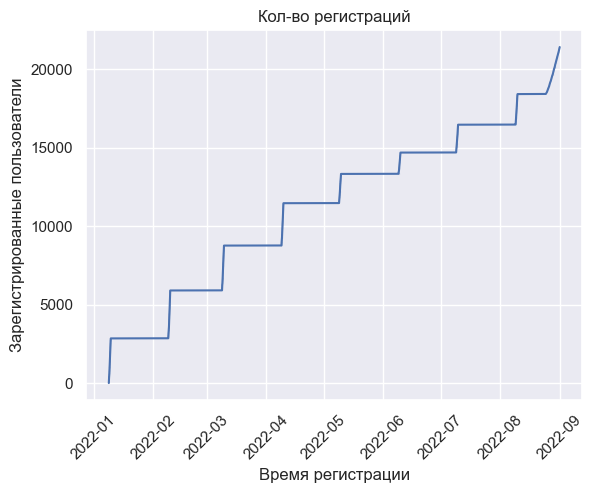

In [33]:
# Весь график (!!!долгая прорисовка!!!)
plt.xticks(rotation=45)

sns.lineplot(users_by_date, x='event_time', y='registered_users')

# Переименования заголовка и осей графика
plt.title("Кол-во регистраций")
plt.xlabel("Время регистрации")
plt.ylabel("Зарегистрированные пользователи")

Text(0, 0.5, 'Зарегистрированные пользователи')

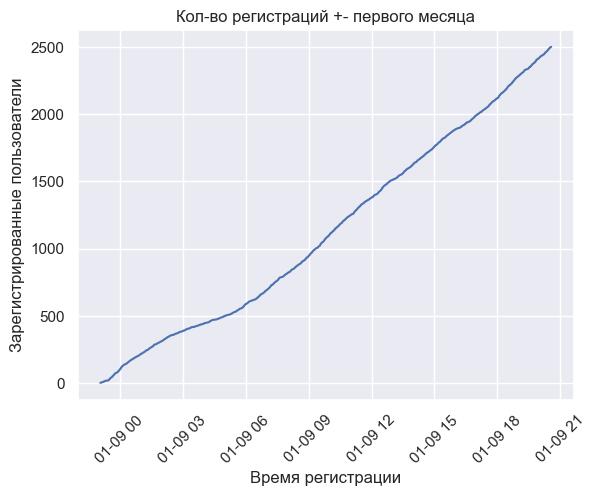

In [34]:
# График +- первого месяца (просмотр динамики)
plt.xticks(rotation=45)

sns.lineplot(users_by_date.head(2500), x='event_time', y='registered_users')

plt.title("Кол-во регистраций +- первого месяца")
plt.xlabel("Время регистрации")
plt.ylabel("Зарегистрированные пользователи")

In [35]:
# Создание колонок с датами и месяцами событий

In [36]:
users_by_date['event_date'] = users_by_date.event_time.dt.date

In [37]:
users_by_date['event_month'] = users_by_date.event_time.dt.month

In [39]:
# Нахождение даты первой регистрации в каждом месяце
print('Даты первой регистрации в каждом месяце')
print()

for month in users_by_date.event_month.unique():
    print(
        users_by_date \
            .query('event_month == @month') \
            .groupby('event_date', as_index=False) \
            .agg({'registered_users': 'min'}) \
            .event_date \
            .head(1) \
            .to_string()
    )

Даты первой регистрации в каждом месяце

0    2022-01-08
0    2022-02-08
0    2022-03-08
0    2022-04-08
0    2022-05-08
0    2022-06-08
0    2022-07-08
0    2022-08-08


Выходит довольно необычный график регистраций. **Рост в течении одного дня**, а затем **полное плато** до момента новой волны регистраций. Подобное поведение можно было бы объяснить **потоковой регистрацией**, когда окно этих самых регистраций открыто в определённый промежуток времени. **Нетипичный подход для Ecommerce**. **Можно предположить, что есть проблемы со сбором данных**. Однако стоит учитывать, что **каждая новая волна начинается 8 числа каждого месяца и длится день**. Подобные обстоятельства могут действительно **является стратегией** компании. Данная ситуация требует уточнений и разбирательств о природе подобного поведения графика